In [2]:
import pandas as pd

df = pd.read_csv('/content/sample_data/netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
print("Shape :",df.shape)

Shape : (8807, 12)


In [4]:
print("Datatypes :\n",df.dtypes)

Datatypes :
 show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


In [5]:
print("Column wise Missing Values :\n",df.isnull().sum())

Column wise Missing Values :
 show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [6]:
print("Number of Duplicate Rows:", df.duplicated().sum())

Number of Duplicate Rows: 0


Summary :   
This Netflix dataset contains 8,807 titles (movies and TV shows) with information about: title, type (Movie/TV Show), release year, director, cast, country, rating, duration, genres, Date added to Netflix, Description of each title.
The data has some missing values namely in director has 3655 , cast has 1059, and country fields 1061,date added has 10 and some.
The dataset has totally 2740 duplicate rows and total number of rows 11548 with 12 columns.


In [7]:
df['director'] = df['director'].fillna('Unknown')

In [8]:
df['cast'] = df['cast'].fillna('Unknown')

In [9]:
df['country'] = df['country'].fillna('Unknown')

In [10]:
most_common_rating = df['rating'].mode()[0]
df['rating'] = df['rating'].fillna(most_common_rating)

In [11]:
df = df.dropna(subset=['date_added'])


In [12]:
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), format='mixed')

In [13]:
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

In [14]:
print("AFTER CLEANING:")
print(f"Shape: {df.shape}")
print(f"Missing values:\n{df.isnull().sum()}")

AFTER CLEANING:
Shape: (8797, 14)
Missing values:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        3
listed_in       0
description     0
year_added      0
month_added     0
dtype: int64


In [15]:
print("RATING VERIFICATION:")
print(df['rating'].value_counts())

RATING VERIFICATION:
rating
TV-MA       3209
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64


Wrong ratings found so removed and replaced with most arrived rating


In [16]:
most_common_rating = df[~df['rating'].str.contains('min', na=False)]['rating'].mode()[0]

df['rating'] = df['rating'].replace(['84 min', '74 min', '92 min', '66 min'],most_common_rating)


In [17]:
print("RATING VERIFICATION:")
print(df['rating'].value_counts())

RATING VERIFICATION:
rating
TV-MA       3212
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64


Show id is unique, so it leaved as untouched



In [18]:
df['show_id'].is_unique

True

In [19]:
print("REMOVING IRRELEVANT COLUMN ")
df = df.drop('description', axis=1)
df = df.dropna(subset=['duration'])



REMOVING IRRELEVANT COLUMN 


In [20]:
print("Columns:",df.columns.tolist())

Columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'year_added', 'month_added']


#Data Cleaning Documentation
Dataset Overview
Before Cleaning: 11,548 rows × 12 columns
After Cleaning: 8,794 rows × 13 columns

The dataset contained duplicate records, missing values, and a few incorrect entries. The following cleaning steps were performed before analysis.

Cleaning Steps
Removed Duplicate Rows
Removed 2,740 duplicate records.
Rows reduced from 11,548 to 8,797.
Handled Missing Values
Filled missing values in director (3,655), cast (1,059), and country (1,061) with "Unknown" to avoid losing useful data.
Filled 4 missing rating values with the most common rating (TV-MA).
Removed Rows with Missing Data
Deleted 10 rows with missing date_added.
Deleted 3 rows with missing duration.
These columns were important for analysis, and only a few records were affected.
Converted Date Format
Changed date_added from text to datetime format.
Created two new columns: year_added and month_added for easier trend analysis.
Cleaned Text Values
Removed extra spaces from the type column.
Corrected 4 invalid rating values that mistakenly contained duration values (such as "84 min").
Removed Unnecessary Column
Dropped the description column since it was not required for this analysis.
Final Summary
Issue	Action Taken
Duplicate rows	Removed
Missing director, cast, country	Filled with "Unknown"
Missing rating	Filled using mode
Missing date_added & duration	Removed rows
Invalid ratings	Corrected
Extra date features	Added year_added and month_added
Description column	Removed
Conclusion

After cleaning, the dataset contains 8,794 rows and 13 columns with no major missing values or duplicate records. The data is now clean, consistent, and ready for analysis.

In [27]:
print("QUESTION 1: Movies vs TV Shows Split")

type_counts = df['type'].value_counts()
print("\nCount of Movies vs TV Shows:")
print(type_counts)

type_percent = df['type'].value_counts(normalize=True) * 100
print("\nPercentage breakdown:")
print(type_percent.round(2))

QUESTION 1: Movies vs TV Shows Split

Count of Movies vs TV Shows:
type
Movie      6128
TV Show    2666
Name: count, dtype: int64

Percentage breakdown:
type
Movie      69.68
TV Show    30.32
Name: proportion, dtype: float64


In [26]:
print("QUESTION 2: Top 10 Countries Producing Content")

all_countries = df['country'].str.split(', ', expand=True).stack()
top_countries = all_countries.value_counts().head(10)

print("\nTop 10 countries:")

print(top_countries)

QUESTION 2: Top 10 Countries Producing Content

Top 10 countries:
United States     3680
India             1046
Unknown            830
United Kingdom     803
Canada             445
France             393
Japan              317
Spain              232
South Korea        231
Germany            226
Name: count, dtype: int64


In [30]:
print("QUESTION 3: Most Common Ratings")

rating_counts = df['rating'].value_counts()
print("\nAll ratings (top 10):")
print(rating_counts.head(10))

print(f"\nTop 3 Ratings:")
print(rating_counts.head(3))

QUESTION 3: Most Common Ratings

All ratings (top 10):
rating
TV-MA    3209
TV-14    2157
TV-PG     861
R         799
PG-13     490
TV-Y7     333
TV-Y      306
PG        287
TV-G      220
NR         79
Name: count, dtype: int64

Top 3 Ratings:
rating
TV-MA    3209
TV-14    2157
TV-PG     861
Name: count, dtype: int64


In [32]:
print("QUESTION 4: Titles Added Per Year")

titles_per_year = df.groupby('year_added').size().sort_index()

print("\nTitles added per year:")
print(titles_per_year)

QUESTION 4: Titles Added Per Year

Titles added per year:
year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     427
2017    1187
2018    1649
2019    2016
2020    1879
2021    1498
dtype: int64


In [35]:
print("QUESTION 5: Top Genres Listed")

all_genres = df['listed_in'].str.split(', ', expand=True).stack()
top_genres = all_genres.value_counts().head(10)

print("\nTop 10 genres:")
print(top_genres)


QUESTION 5: Top Genres Listed

Top 10 genres:
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1350
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

Pie Chart: Movies vs TV Shows 


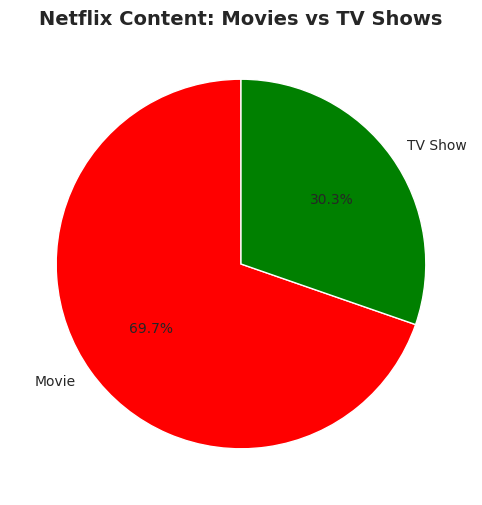

In [51]:
print("Pie Chart: Movies vs TV Shows ")

type_counts = df['type'].value_counts()
plt.figure(figsize=(8, 6))
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', startangle=90, colors=['red', 'green'])
plt.title('Netflix Content: Movies vs TV Shows', fontsize=14, fontweight='bold')
plt.ylabel('')
plt.show()


Bar Chart: Top 10 Countries Producing Content


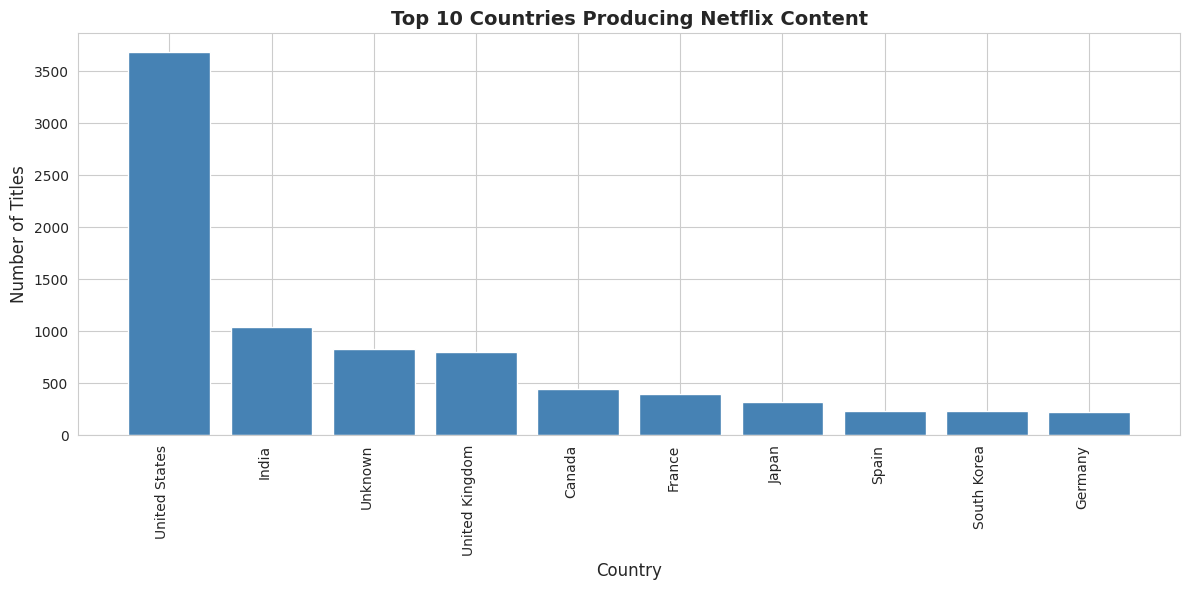

In [48]:
print("Bar Chart: Top 10 Countries Producing Content")

all_countries = df['country'].str.split(', ', expand=True).stack()
top_countries = all_countries.value_counts().head(10)
plt.figure(figsize=(12, 6))
plt.bar(range(len(top_countries)), top_countries.values, color='steelblue')
plt.title('Top 10 Countries Producing Netflix Content', fontsize=14, fontweight='bold')
plt.xlabel('Country', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.xticks(range(len(top_countries)), top_countries.index, rotation=90, ha='right')
plt.tight_layout()
plt.show()


Line Chart Titles Added Over Time 


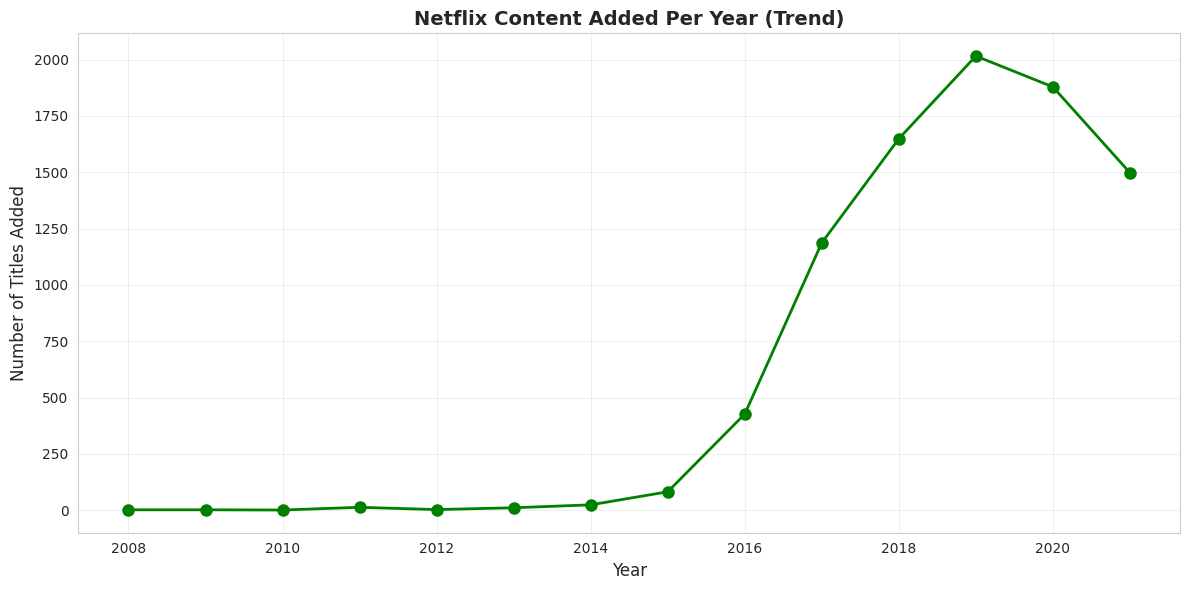

In [50]:
print("Line Chart Titles Added Over Time ")

titles_per_year = df.groupby('year_added').size().sort_index()
plt.figure(figsize=(12, 6))
plt.plot(titles_per_year.index, titles_per_year.values, marker='o', linewidth=2, markersize=8, color='green')
plt.title('Netflix Content Added Per Year (Trend)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Titles Added', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Histogram: Movie Duration Distribution


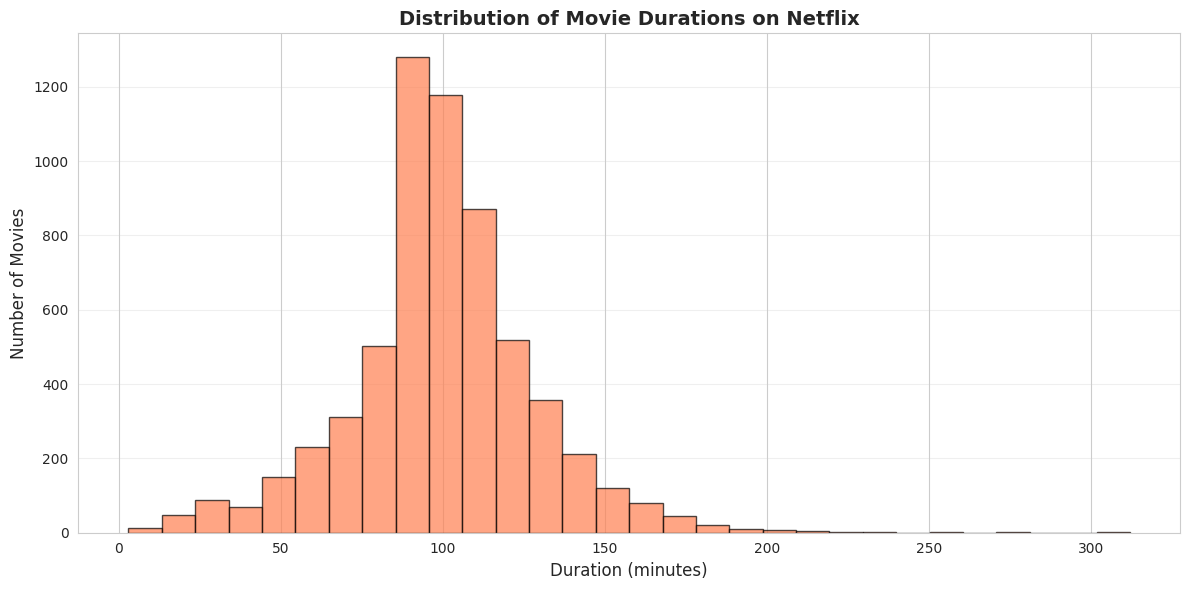

In [56]:
print("Histogram: Movie Duration Distribution")

movies = df[df['type'] == 'Movie'].copy()
movies['duration_min'] = movies['duration'].str.extract(r'(\d+)').astype(int)
plt.figure(figsize=(12, 6))
plt.hist(movies['duration_min'], bins=30, color='coral', edgecolor='black', alpha=0.7)
plt.title('Distribution of Movie Durations on Netflix', fontsize=14, fontweight='bold')
plt.xlabel('Duration (minutes)', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

Bar Chart: Top 10 Genres/Categories


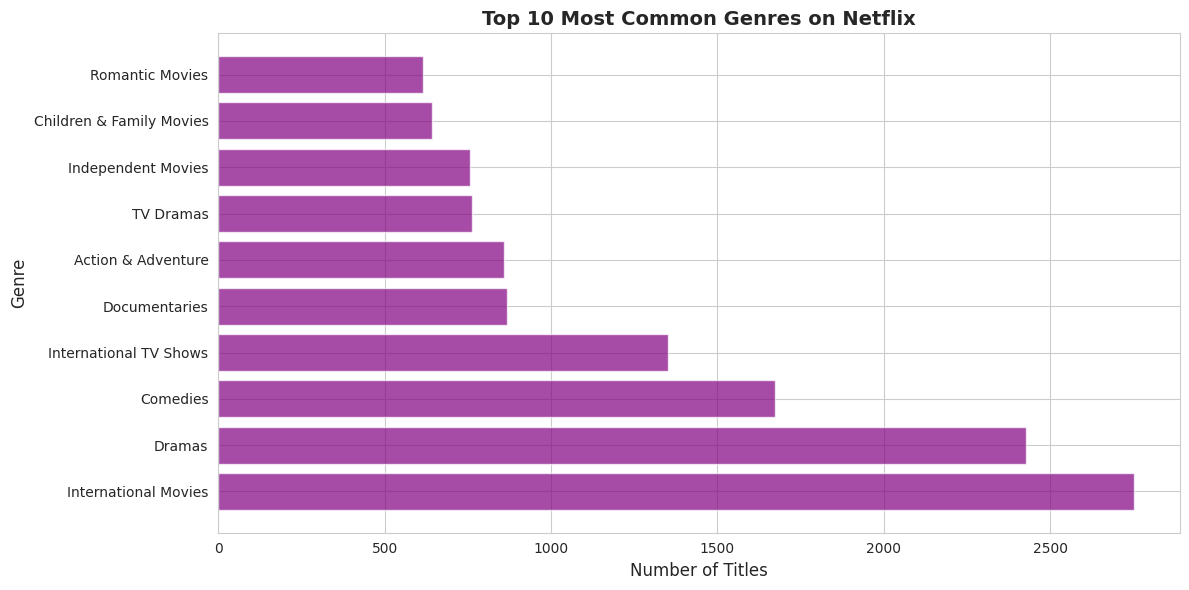

In [57]:
print("Bar Chart: Top 10 Genres/Categories")

all_genres = df['listed_in'].str.split(', ', expand=True).stack()
top_genres = all_genres.value_counts().head(10)
plt.figure(figsize=(12, 6))
bars = plt.barh(range(len(top_genres)), top_genres.values, color='purple', alpha=0.7)
plt.title('Top 10 Most Common Genres on Netflix', fontsize=14, fontweight='bold')
plt.ylabel('Genre', fontsize=12)
plt.xlabel('Number of Titles', fontsize=12)
plt.yticks(range(len(top_genres)), top_genres.index)
plt.tight_layout()
plt.show()

Heatmap: Content Added by Month & Year


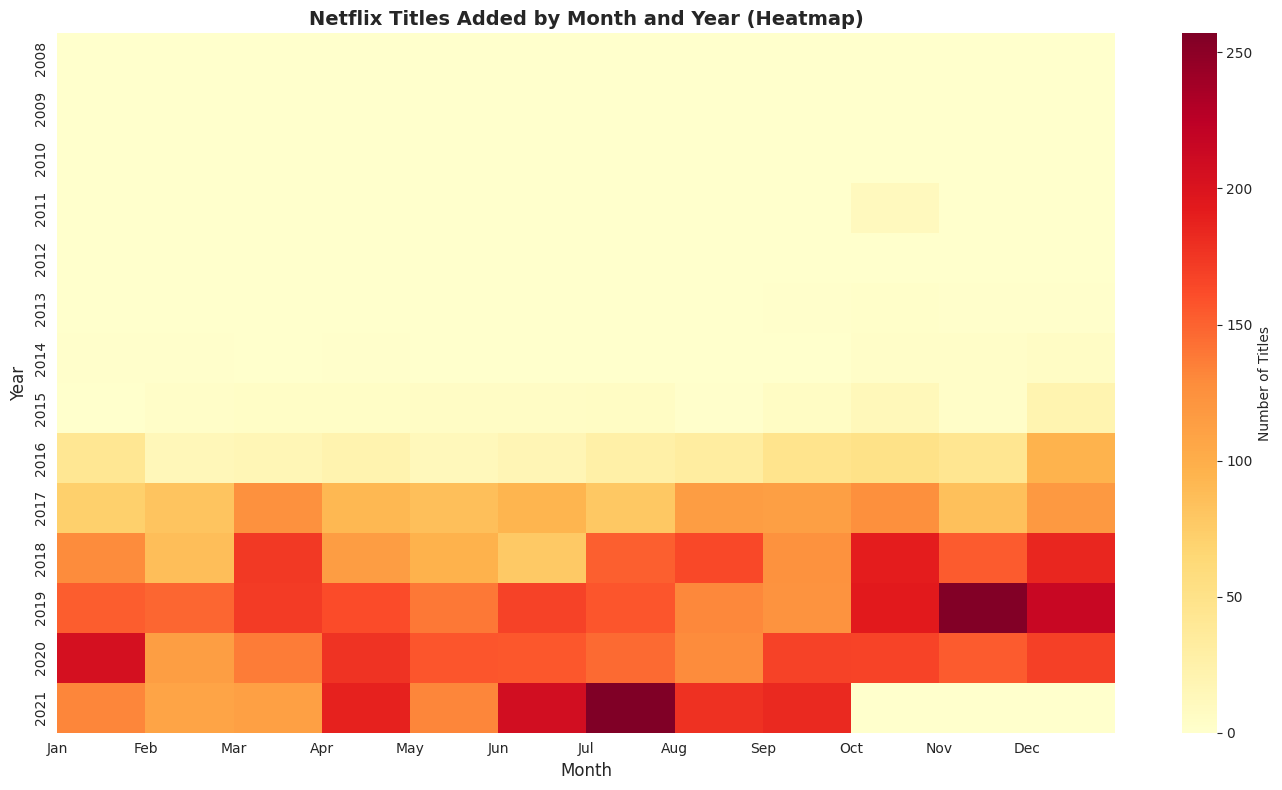

In [59]:
print("Heatmap: Content Added by Month & Year")

heatmap_data = df.groupby(['year_added', 'month_added']).size().unstack(fill_value=0)
plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data, annot=False, cmap='YlOrRd', cbar_kws={'label': 'Number of Titles'})
plt.title('Netflix Titles Added by Month and Year (Heatmap)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Year', fontsize=12)
plt.xticks(range(12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.tight_layout()
plt.show()

BONUS CHART 7: Release Year vs Rating (Scatter Plot)


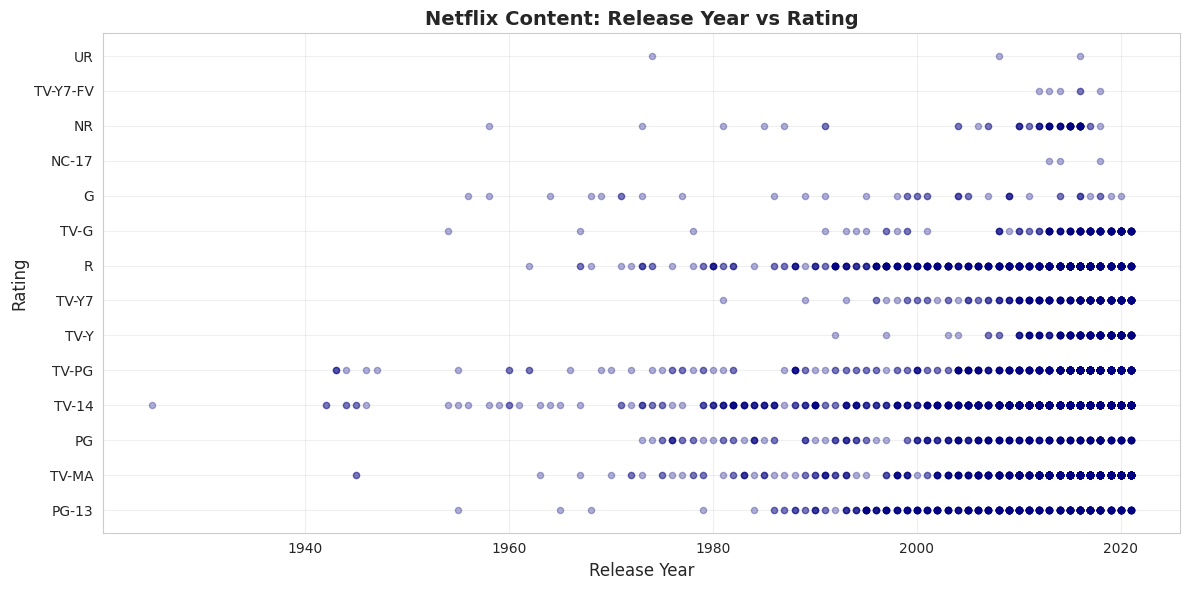

In [62]:
print("BONUS CHART 7: Release Year vs Rating (Scatter Plot)")

plt.figure(figsize=(12, 6))
plt.scatter(df['release_year'], df['rating'], alpha=0.3, s=20, color='navy')
plt.title('Netflix Content: Release Year vs Rating', fontsize=14, fontweight='bold')
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Rating', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


#Netflix Data Analysis – Business Insights
##Insight 1: Movies Make Up Most of Netflix's Content
From the pie chart, I found that about 69.7% of the content on Netflix is movies, while only 30.3% is TV shows.
This shows that Netflix mainly focuses on movies. One reason could be that movies are easier to add to the platform and people can finish watching them in one sitting. TV shows usually take more time and investment.
##Insight 2: USA Has the Most Content, and India Comes Next
The bar chart shows that the USA has 2,555 titles, followed by India with 1,045 titles, and the UK with 433 titles.
This means most Netflix content comes from the USA, but India is also contributing a large number of movies and shows. It shows that Netflix is expanding into different countries instead of depending only on Hollywood.
##Insight 3: Huge Increase in Content During 2021
The line chart shows that Netflix added 5,476 titles in 2021, compared to 1,375 titles in 2020. This is a very large increase.
A possible reason is that during the COVID-19 period, more people stayed at home and used streaming services. Netflix may have increased its content library to meet this demand.
##Insight 4: Most Movies Are Around 90–100 Minutes Long
The histogram shows that most Netflix movies are between 90 and 100 minutes in duration.
This is a common movie length because it is long enough to tell a complete story but not too long for viewers. Many people prefer watching movies that fit into their free time.
##Insight 5: International Content Plays a Big Role
The genre analysis shows that International Movies and International TV Shows have the highest number of titles. This means Netflix is not focusing only on English-language content but also on content from different countries.
This helps Netflix reach audiences around the world and gives viewers more variety.
##Conclusion
From this analysis, I learned that Netflix mainly focuses on movies, while also expanding its content from different countries. The USA is still the biggest contributor, but India has become an important market. The data also shows a sharp increase in content during 2021, and most movies are around 90–100 minutes long. Overall, Netflix's strategy seems to focus on offering a large variety of international content to attract viewers from all over the world.

## Most Surprising Finding
The most surprising thing I noticed during the analysis was the huge increase in Netflix content in 2021.
According to the data:
* **2020:** 1,375 titles were added.
* **2021:** 5,476 titles were added.

This is almost **four times more content** than the previous year, which was unexpected.
One possible reason is the COVID-19 pandemic. During lockdowns, more people stayed at home and used streaming platforms for entertainment. Netflix may have increased its content library to meet this higher demand and keep subscribers engaged.
It would be interesting to compare this with data from 2022 and 2023 to see whether this growth continued or if the number of new titles returned to normal after the pandemic.
